In [1]:

import json
import os
from collections import defaultdict
import pandas as pd

def is_valid_data_file(file_name:str) -> bool:
    return file_name.endswith("json") or file_name.endswith("txt")

def json_to_tree_data(data: dict):
    def item_to_list_of_entries(item) -> list[dict]:
        surrounding_information = {prop: item[prop]
                                   for prop in ["problem_name", "pRef_method"]}
        surrounding_information = {"problem": item["problem_name"],
                                   "pRef_method": item["pRef_method"]}

        entries = item["results_by_tree"]
        entries = [thing for thing in entries if "order_tree" in thing]  

        def convert_order_tree(order_tree, accumulator = None, current_depth: int = 0):
            if accumulator is None:
                accumulator = defaultdict(list)
            accumulator[current_depth].append(order_tree["own"])
            if len(order_tree["matching"]) > 0:
                convert_order_tree(order_tree["matching"], accumulator, current_depth+1)

            if len(order_tree["unmatching"]) > 0:
                convert_order_tree(order_tree["unmatching"], accumulator, current_depth+1)

            return accumulator
        def convert_tree_to_averages_by_level(entry):
            ps_search_info = {prop: entry[prop]
                                   for prop in ["ps_budget", "ps_population", "metrics"]}
            tree_structure = entry["order_tree"]
            just_depths = convert_order_tree(tree_structure)
            #average_orders_by_depth = {f"average_at_{depth}": np.average(orders)
            #                  for depth, orders in just_depths.items()}
            #standard_deviations = {f"sd_at_{depth}": np.std(orders)
            #                  for depth, orders in just_depths.items()}
            #overall_average = {"overall_average": np.average(list(itertools.chain(*(just_depths.values()))))}
            core_info_trees = [{"depth": depth,
                               "order": order}
                               for depth in just_depths
                                for order in just_depths[depth]
                               ]
            core_info_trees = [(surrounding_information | ps_search_info | core_tree)
            for core_tree in core_info_trees]
            return core_info_trees


        entries = [datapoint 
                   for converted_entry in map(convert_tree_to_averages_by_level, entries)
                   for datapoint in converted_entry ]
        return entries

    return [entry for item in data for entry in item_to_list_of_entries(item)]

def convert_tree_data_to_df(input_directory, output_filename):

    all_dicts = []
    # Iterate through all files in the input directory
    for filename in os.listdir(input_directory):
        # Construct full file path
        file_path = os.path.join(input_directory, filename)

        # Check if the file is a JSON file
        if not os.path.isfile(file_path):
            continue

        if not is_valid_data_file(file_path):
            continue


        with open(file_path, 'r') as file:
            data = json.load(file)
            entries = json_to_tree_data(data)
            all_dicts.extend(entries)

    # Convert list of dictionaries to DataFrame
    df = pd.DataFrame(all_dicts)

    # Write the DataFrame to a CSV file
    df.to_csv(output_filename, index=False)

def filter_dataframe(df, **kwargs):
    df = df.copy()  # Make a copy of the DataFrame to avoid modifying the original
    for col, value in kwargs.items():
        if col in df.columns:
            df = df[df[col] == value]
        else:
            raise ValueError(f"Column '{col}' not found in dataframe.")
    return df






In [3]:
# run_directory =  r"C:\Users\gac8\Desktop\CondorResults\VDT\compareown\all_final_runs"
run_directory = r"/Users/gian/Desktop/CondorResults/VDT/compareown/all_final_runs"
raw_tree_data_directory = os.path.join(run_directory, "data")
tree_data_file = os.path.join(run_directory, "tree_data_v2.csv")
convert_tree_data_to_df(raw_tree_data_directory, tree_data_file)

In [4]:
all_tree_data = pd.read_csv(tree_data_file)
display(all_tree_data)

,problem,pRef_method,ps_budget,ps_population,metrics,depth,order
0,SAT_S,uniform,5000,100,variance,0,2
1,SAT_S,uniform,5000,100,variance,1,2
2,SAT_S,uniform,5000,100,variance,1,2
3,SAT_S,uniform,5000,100,variance,2,6
4,SAT_S,uniform,5000,100,variance,2,3
...,...,...,...,...,...,...,...
552677,BT,Tabu,5000,100,variance estimated_atomicity,5,2
552678,BT,Tabu,5000,100,variance estimated_atomicity,5,3
552679,BT,Tabu,5000,100,variance estimated_atomicity,5,2
552680,BT,Tabu,5000,100,variance estimated_atomicity,5,2


In [13]:



df = filter_dataframe(all_tree_data, pRef_method = "GA", ps_budget = 5000, ps_population=100)
df = df[df["depth"].isin([0, 1, 2, 3, 4])]

display(df)


,problem,pRef_method,ps_budget,ps_population,metrics,depth,order
245,SAT_S,GA,5000,100,variance,0,3
246,SAT_S,GA,5000,100,variance,1,6
247,SAT_S,GA,5000,100,variance,1,2
248,SAT_S,GA,5000,100,variance,2,3
249,SAT_S,GA,5000,100,variance,2,5
...,...,...,...,...,...,...,...
552238,BT,GA,5000,100,variance estimated_atomicity,4,1
552239,BT,GA,5000,100,variance estimated_atomicity,4,2
552240,BT,GA,5000,100,variance estimated_atomicity,4,4
552241,BT,GA,5000,100,variance estimated_atomicity,4,2


In [14]:
# making the data prettier

df.rename(columns={'metrics': 'variant'}, inplace=True)
variant_mapping = {"variance": "PS-W", "variance estimated_atomicity": "PS-WA"}
df['variant'] = df['variant'].map(variant_mapping)

problem_mapping = {"BT":"BT", 
                   "GC_S": "GC_anna", 
                   "GC_L": "GC_jean", 
                   "SAT_S": "SAT_20", 
                   "SAT_M": "SAT_50", 
                   "SAT_L": "SAT_100"}

df["problem"] = df["problem"].map(problem_mapping)

display(df)





,problem,pRef_method,ps_budget,ps_population,variant,depth,order
245,SAT_20,GA,5000,100,PS-W,0,3
246,SAT_20,GA,5000,100,PS-W,1,6
247,SAT_20,GA,5000,100,PS-W,1,2
248,SAT_20,GA,5000,100,PS-W,2,3
249,SAT_20,GA,5000,100,PS-W,2,5
...,...,...,...,...,...,...,...
552238,BT,GA,5000,100,PS-WA,4,1
552239,BT,GA,5000,100,PS-WA,4,2
552240,BT,GA,5000,100,PS-WA,4,4
552241,BT,GA,5000,100,PS-WA,4,2


,problem,pRef_method,ps_budget,ps_population,variant,depth,order
298,SAT_20,GA,5000,100,PS-WA,0,2
299,SAT_20,GA,5000,100,PS-WA,1,2
300,SAT_20,GA,5000,100,PS-WA,1,2
301,SAT_20,GA,5000,100,PS-WA,2,2
302,SAT_20,GA,5000,100,PS-WA,2,2
...,...,...,...,...,...,...,...
552234,BT,GA,5000,100,PS-WA,4,2
552236,BT,GA,5000,100,PS-WA,4,2
552239,BT,GA,5000,100,PS-WA,4,2
552241,BT,GA,5000,100,PS-WA,4,2


In [18]:
display(df[(df["order"] > 10)])

,problem,pRef_method,ps_budget,ps_population,variant,depth,order
1172,SAT_50,GA,5000,100,PS-W,1,17
1174,SAT_50,GA,5000,100,PS-W,2,26
1175,SAT_50,GA,5000,100,PS-W,2,13
1178,SAT_50,GA,5000,100,PS-W,3,25
1180,SAT_50,GA,5000,100,PS-W,3,27
...,...,...,...,...,...,...,...
552179,BT,GA,5000,100,PS-W,4,11
552180,BT,GA,5000,100,PS-W,4,23
552181,BT,GA,5000,100,PS-W,4,15
552182,BT,GA,5000,100,PS-W,4,15


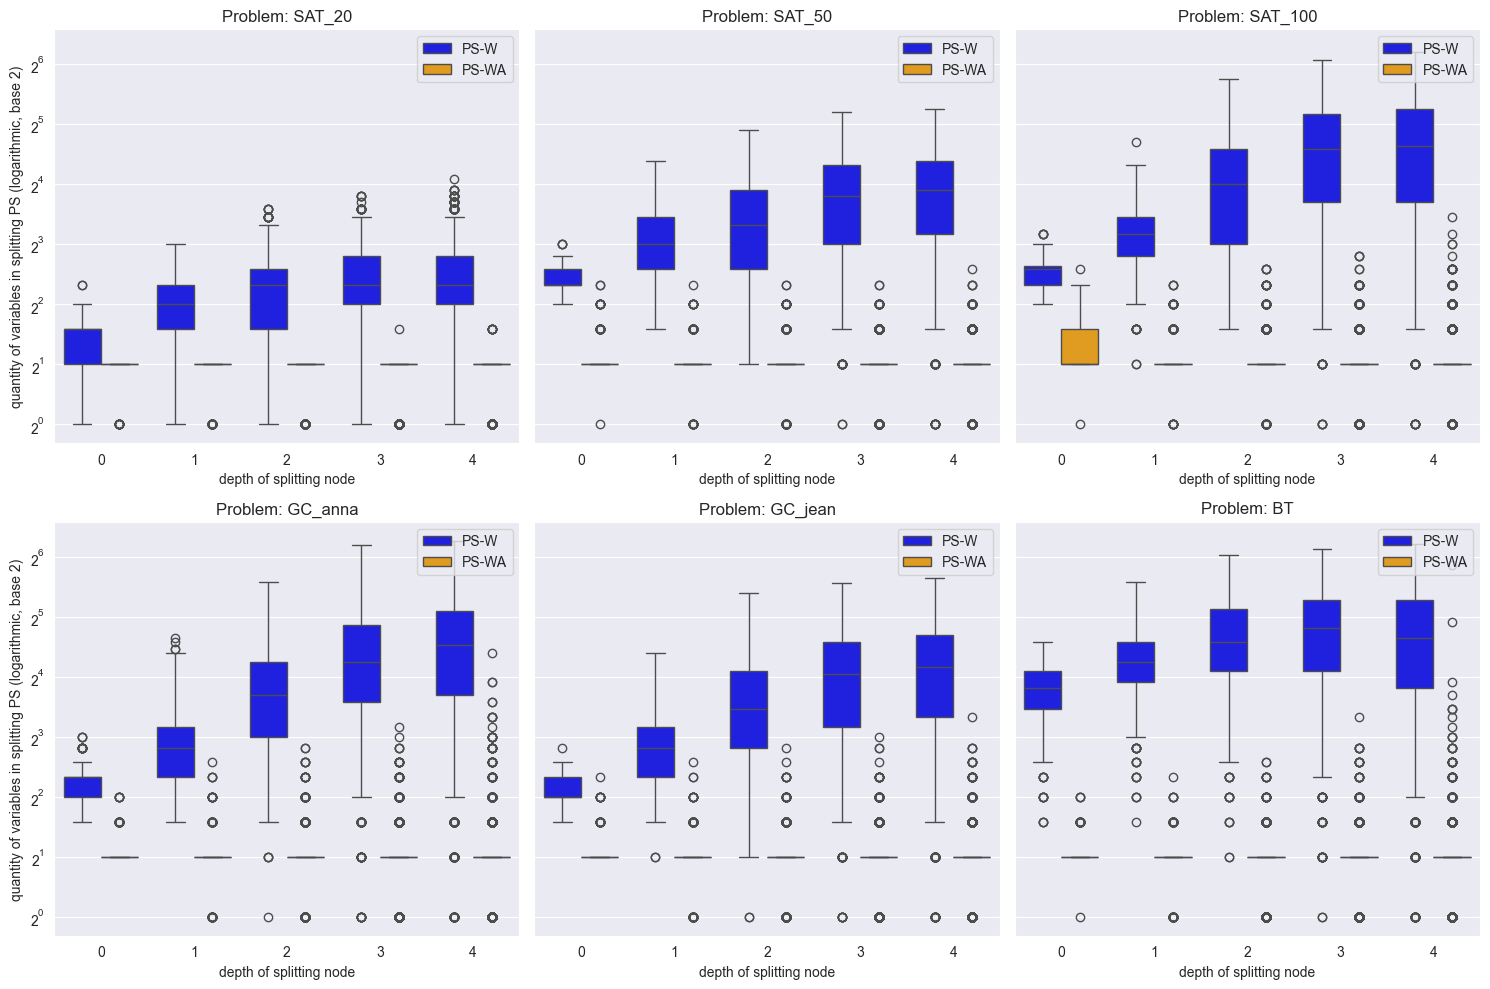

In [27]:
import utils
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Create box plots
problems = df['problem'].unique()
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

for ax, problem in zip(axes.flatten(), problems):
    sns.boxplot(
        x='depth', y='order', hue='variant',
        data=df[df['problem'] == problem],
        ax=ax, palette={"PS-W": "blue", "PS-WA": "orange"},
    )
    
    # sns.violinplot(
    #     x='depth', y='order', hue='variant',
    #     data=df[df['problem'] == problem],
    #     ax=ax, palette={"PS-W": "darkgrey", "PS-WA": "lightgrey"},
    #     split=True
    # )
    ax.set_title(f'Problem: {problem}')
    ax.set_ylabel("quantity of variables in splitting PS (logarithmic, base 2)")
    ax.set_xlabel("depth of splitting node")
    ax.set_yscale('log', base=2)
    ax.legend(loc='upper right')

# Adjust layout and show the plot
plt.tight_layout()


plt.savefig(os.path.join(run_directory, "boxplots", r"boxplot"+utils.get_formatted_timestamp()+".pdf"))    

plt.show()